In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import re

In [3]:
carpeta = Path("raw")

archivos_csv = list(carpeta.glob("*.csv"))

print("Archivos encontrados:")
for archivo in archivos_csv:
    print(archivo)

dataframes = {}

for archivo in archivos_csv:
    dataframes[archivo.stem] = pd.read_csv(archivo)

print(dataframes.keys())

Archivos encontrados:
raw/spotify_dataset.csv
raw/the_grammy_awards.csv
dict_keys(['spotify_dataset', 'the_grammy_awards'])


In [28]:
#counting rows that are repeated in their entirety
df = dataframes["the_grammy_awards"]
print(df.duplicated().sum())

0


In [29]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["year"].value_counts()

year
2019    433
2007    111
2008    111
2006    110
2010    109
       ... 
1968     40
1962     39
1960     39
1959     35
1958     28
Name: count, Length: 62, dtype: int64

In [30]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["title"].value_counts()

title
62nd Annual GRAMMY Awards  (2019)    433
50th Annual GRAMMY Awards  (2007)    111
51st Annual GRAMMY Awards  (2008)    111
49th Annual GRAMMY Awards  (2006)    110
53rd Annual GRAMMY Awards  (2010)    109
                                    ... 
11th Annual GRAMMY Awards  (1968)     40
5th Annual GRAMMY Awards  (1962)      39
3rd Annual GRAMMY Awards  (1960)      39
2nd Annual GRAMMY Awards  (1959)      35
1st Annual GRAMMY Awards  (1958)      28
Name: count, Length: 62, dtype: int64

In [31]:
df = dataframes["the_grammy_awards"].copy()

title_df = df[["title"]].dropna().copy()

title_df["title_normalizado"] = (
    title_df["title"]
    .str.strip()
    .str.lower()
)

repetidos_forma = (
    title_df.groupby("title_normalizado")["title"]
    .agg(["nunique", lambda x: list(x.unique())])
    .reset_index()
)

repetidos_forma.columns = ["title_normalizado", "formas_distintas", "variantes"]
repetidos_forma = repetidos_forma[repetidos_forma["formas_distintas"] > 1]

display(repetidos_forma)

,title_normalizado,formas_distintas,variantes


In [32]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["published_at"].value_counts()

published_at
2017-11-28T00:03:45-08:00    4205
2020-05-19T05:10:28-07:00     433
2018-12-06T23:48:49-08:00      86
2018-05-22T03:08:24-07:00      86
Name: count, dtype: int64

In [33]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["category"].value_counts()

category
Song Of The Year                                                   70
Record Of The Year                                                 69
Album Of The Year                                                  66
Best Opera Recording                                               64
Best Album Notes                                                   63
                                                                   ..
Best Sacred Performance (Musical)                                   1
Best Jazz Performance - Small Group Or Soloist With Small Group     1
Best Jazz Performance - Large Group Or Soloist With Large Group     1
Best Contemporary Vocal Performance By A Group                      1
Best Classical Performance - Operatic Or Choral                     1
Name: count, Length: 638, dtype: int64

In [34]:
df = dataframes["the_grammy_awards"].copy()

category_df = df[["category"]].dropna().copy()

category_df["category_normalizado"] = (
    category_df["category"]
    .str.strip()
    .str.lower()
)

repetidos_forma = (
    category_df.groupby("category_normalizado")["category"]
    .agg(["nunique", lambda x: list(x.unique())])
    .reset_index()
)

repetidos_forma.columns = ["category_normalizado", "formas_distintas", "variantes"]
repetidos_forma = repetidos_forma[repetidos_forma["formas_distintas"] > 1]

display(repetidos_forma)

,category_normalizado,formas_distintas,variantes
96,best classical performance - instrumental solo...,2,[Best Classical Performance - Instrumental Sol...
307,best instrumental soloist performance (without...,2,[Best Instrumental Soloist Performance (withou...
310,best instrumental soloist(s) performance (with...,2,[Best Instrumental Soloist(s) Performance (wit...
536,best small ensemble performance (with or witho...,2,[Best Small Ensemble Performance (with or with...
567,"best southern, country, or bluegrass gospel album",2,"[Best Southern, Country, Or Bluegrass Gospel A..."
572,best spoken word album for children,2,"[Best Spoken Word Album For Children, Best Spo..."
627,"remixer of the year, non-classical",3,"[Remixer of the Year, Non-Classical, Remixer O..."


In [35]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["nominee"].value_counts()

nominee
Bridge Over Troubled Water    7
Robert Woods                  7
Berlioz: Requiem              7
Steven Epstein                7
David Frost                   6
                             ..
Push The Button               1
The Art Of Romance            1
Devils & Dust                 1
B.Y.O.B.                      1
Virtuoso                      1
Name: count, Length: 4131, dtype: int64

In [36]:
df = dataframes["the_grammy_awards"].copy()

nominee_df = df[["nominee"]].dropna().copy()

nominee_df["nominee_normalizado"] = (
    nominee_df["nominee"]
    .str.strip()
    .str.lower()
)

repetidos_forma = (
    nominee_df.groupby("nominee_normalizado")["nominee"]
    .agg(["nunique", lambda x: list(x.unique())])
    .reset_index()
)

repetidos_forma.columns = ["nominee_normalizado", "formas_distintas", "variantes"]
repetidos_forma = repetidos_forma[repetidos_forma["formas_distintas"] > 1]

display(repetidos_forma)

,nominee_normalizado,formas_distintas,variantes


In [37]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["artist"].value_counts()

artist
(Various Artists)                                          66
U2                                                         18
Aretha Franklin                                            16
Bruce Springsteen                                          13
Ella Fitzgerald                                            13
                                                           ..
Rihanna Featuring Jay-Z                                     1
Common Featuring Kanye West                                 1
Lupe Fiasco Featuring Jill Scott                            1
Gerald Levert                                               1
David Seville And The Chipmunks (Ross Bagdasarian, Sr.)     1
Name: count, Length: 1658, dtype: int64

In [38]:
df = dataframes["the_grammy_awards"].copy()

artistas_df = df[["artist"]].dropna().copy()

artistas_df["artist_normalizado"] = (
    artistas_df["artist"]
    .str.strip()
    .str.lower()
)

repetidos_forma = (
    artistas_df.groupby("artist_normalizado")["artist"]
    .agg(["nunique", lambda x: list(x.unique())])
    .reset_index()
)

repetidos_forma.columns = ["artist_normalizado", "formas_distintas", "variantes"]
repetidos_forma = repetidos_forma[repetidos_forma["formas_distintas"] > 1]

display(repetidos_forma)

,artist_normalizado,formas_distintas,variantes
542,for king & country,2,"[for KING & COUNTRY, For King & Country]"
1546,tobymac,2,"[TobyMac, Tobymac]"


In [39]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["workers"].value_counts()

workers
John Williams, composer (John Williams)                                                                                                                                          20
Vladimir Horowitz, artist                                                                                                                                                        15
Henry Mancini, arranger (Henry Mancini)                                                                                                                                           8
Robert Shaw, conductor (Atlanta Symphony Chorus; Atlanta Symphony Orchestra)                                                                                                      7
(Chicago Symphony Orchestra)                                                                                                                                                      7
                                                                                            

In [40]:
df = dataframes["the_grammy_awards"].copy()

workers_df = df[["workers"]].dropna().copy()

workers_df["workers_normalizado"] = (
    workers_df["workers"]
    .str.strip()
    .str.lower()
)

repetidos_forma = (
    workers_df.groupby("workers_normalizado")["workers"]
    .agg(["nunique", lambda x: list(x.unique())])
    .reset_index()
)

repetidos_forma.columns = ["workers_normalizado", "formas_distintas", "variantes"]
repetidos_forma = repetidos_forma[repetidos_forma["formas_distintas"] > 1]

display(repetidos_forma)

,workers_normalizado,formas_distintas,variantes
1801,"peter deaquino, daniel ho & sterling seaton, e...",2,"[Peter DeAquino, Daniel Ho & Sterling Seaton, ..."


In [41]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["img"].value_counts()

img
https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/John%2BWilliams/John%2520Williams_1_1_1597170495.jpg?itok=GsnrkP98               26
https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/U2/U2_1_1_1578385236.jpg?itok=rQVhxxhL                                           22
https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Vladimir%2BHorowitz/Vladimir%2520Horowitz_1_1_1597176026.jpg?itok=QiT9d29e       21
https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Henry%2BMancini/Henry%2520Mancini_1_1_1581553583.jpg?itok=oMIyl-mj               20
https://www.grammy.com/sites/com/files/styles/artist_circle/public/georgsolti-spotlight-78824961.png?itok=rNrB7-r2                                          20
                                                                                                                                                            ..
https://www.grammy.com/sites/com/files/sty

In [42]:
# Value counts o duplicated data 
# Invoice id or unique identifier for each transaction 
dataframes["the_grammy_awards"]["winner"].value_counts()

winner
True    4810
Name: count, dtype: int64

In [43]:
#number of times the track_id is repeated
vc = dataframes["the_grammy_awards"]["img"].value_counts()
vc[vc > 1]

img
https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/John%2BWilliams/John%2520Williams_1_1_1597170495.jpg?itok=GsnrkP98               26
https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/U2/U2_1_1_1578385236.jpg?itok=rQVhxxhL                                           22
https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Vladimir%2BHorowitz/Vladimir%2520Horowitz_1_1_1597176026.jpg?itok=QiT9d29e       21
https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Henry%2BMancini/Henry%2520Mancini_1_1_1581553583.jpg?itok=oMIyl-mj               20
https://www.grammy.com/sites/com/files/styles/artist_circle/public/georgsolti-spotlight-78824961.png?itok=rNrB7-r2                                          20
                                                                                                                                                            ..
https://www.grammy.com/sites/com/files/sty

In [44]:
df = dataframes["the_grammy_awards"].copy()

df = df.dropna(subset=["img", "artist"])

df["img"] = df["img"].str.strip()
df["artist"] = df["artist"].str.strip()

revision_img = (
    df.groupby("img")["artist"]
    .nunique()
    .reset_index(name="artists_distintos")
)

img_inconsistentes = revision_img[revision_img["artists_distintos"] > 1]
display(img_inconsistentes)

,img,artists_distintos
10,https://www.grammy.com/sites/com/files/styles/...,2
11,https://www.grammy.com/sites/com/files/styles/...,3
12,https://www.grammy.com/sites/com/files/styles/...,4
22,https://www.grammy.com/sites/com/files/styles/...,2
25,https://www.grammy.com/sites/com/files/styles/...,2
...,...,...
1055,https://www.grammy.com/sites/com/files/styles/...,2
1058,https://www.grammy.com/sites/com/files/styles/...,3
1060,https://www.grammy.com/sites/com/files/styles/...,2
1064,https://www.grammy.com/sites/com/files/styles/...,4


In [45]:
df = dataframes["the_grammy_awards"].copy()

df = df.dropna(subset=["img", "artist"])

df["img"] = df["img"].astype(str).str.strip()
df["artist"] = df["artist"].astype(str).str.strip()

revision_img = (
    df.groupby("img")
    .agg(
        artists_distintos=("artist", "nunique"),
        artistas=("artist", lambda x: ", ".join(sorted(x.unique())))
    )
    .reset_index()
)

img_inconsistentes = revision_img[revision_img["artists_distintos"] > 1]

display(img_inconsistentes.head(10))

,img,artists_distintos,artistas
10,https://www.grammy.com/sites/com/files/styles/...,2,"Alison Krauss & Union Station, Alison Krauss A..."
11,https://www.grammy.com/sites/com/files/styles/...,3,"Andre Previn, André Previn, David Rose And His..."
12,https://www.grammy.com/sites/com/files/styles/...,4,"B.B. King, B.B. King & Dr. John, B.B. King & E..."
22,https://www.grammy.com/sites/com/files/styles/...,2,"India.Arie, India.Arie & Dobet Gnahore"
25,https://www.grammy.com/sites/com/files/styles/...,2,"Linda Ronstadt, Linda Ronstadt & Aaron Neville"
26,https://www.grammy.com/sites/com/files/styles/...,2,"Loretta Lynn, Loretta Lynn & Jack White"
33,https://www.grammy.com/sites/com/files/styles/...,2,"(Various Artists), Gulzar, A.R. Rahman & Tanvi..."
38,https://www.grammy.com/sites/com/files/styles/...,2,"Adele, Adele Adkins & Paul Epworth, songwriter..."
43,https://www.grammy.com/sites/com/files/styles/...,4,"Al Green, Al Green & Lyle Lovett, Al Green Fea..."
48,https://www.grammy.com/sites/com/files/styles/...,5,"Alan Menken & Glenn Slater, songwriters (Mandy..."


In [46]:
import re
import unicodedata

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

df = dataframes["the_grammy_awards"].copy()

df = df.dropna(subset=["img", "artist"]).copy()
df["img"] = df["img"].astype(str).str.strip()
df["artist"] = df["artist"].astype(str).str.strip()

def normalizar_texto(texto):
    if pd.isna(texto):
        return ""


    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")

    # quitar apodos entre comillas
    texto = re.sub(r'"[^"]*"', " ", texto)
    texto = re.sub(r"'[^']*'", " ", texto)

    # mover artículo final al inicio: "Black Keys, The" -> "The Black Keys"
    texto = re.sub(r"^\s*(.+?)\s*,\s*(the|a|an)\s*$", r"\2 \1", texto)

    # normalizar conectores
    texto = texto.replace("&", " and ")
    texto = re.sub(r"\by\b", " and ", texto)

    # quitar paréntesis
    texto = re.sub(r"\(.*?\)", " ", texto)

    # limpiar signos
    texto = re.sub(r"[^\w\s/-]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    # para comparar grupos/artistas, quitamos artículo inicial
    texto = re.sub(r"^(the|a|an)\s+", "", texto).strip()

    return texto

def separar_artistas(texto):
    texto = normalizar_texto(texto)
    if not texto:
        return []

    # todos estos conectores se consideran separadores de colaboración
    texto = re.sub(r"\b(feat\.?|featuring|ft\.?|with|and|x)\b", ",", texto)

    partes = re.split(r"[,/;]+", texto)

    return sorted({p.strip() for p in partes if p.strip()})

df["artist_normalizado"] = df["artist"].apply(normalizar_texto)
df["artist_lista"] = df["artist"].apply(separar_artistas)

revision_img = (
    df.groupby("img")
    .agg(
        artists_distintos_original=("artist", "nunique"),
        artists_distintos_normalizados=("artist_normalizado", "nunique"),
        artistas_originales=("artist", lambda x: " | ".join(sorted(x.unique()))),
        artistas_normalizados=("artist_normalizado", lambda x: " | ".join(sorted(x.unique()))),
        artistas_individuales_detectados=("artist_lista", lambda x: sorted(set(a for lista in x for a in lista)))
    )
    .reset_index()
)

def clasificar_fila(row):
    artistas_originales = row["artistas_originales"].split(" | ")
    listas = [set(separar_artistas(a)) for a in artistas_originales if a.strip()]

    if row["artists_distintos_original"] > 1 and row["artists_distintos_normalizados"] == 1:
        return "mismo artista escrito diferente"

    hay_solapamiento = False
    for i in range(len(listas)):
        for j in range(i + 1, len(listas)):
            if listas[i].intersection(listas[j]):
                hay_solapamiento = True
                break
        if hay_solapamiento:
            break

    if hay_solapamiento:
        return "posible colaboracion"

    if row["artists_distintos_normalizados"] > 1:
        return "posible conflicto"

    return "sin problema visible"

revision_img["estado_validacion"] = revision_img.apply(clasificar_fila, axis=1)

img_revision = revision_img[
    (revision_img["artists_distintos_original"] > 1) |
    (revision_img["artists_distintos_normalizados"] > 1)
].copy()

print(f"Total de registros para revisión: {len(img_revision)}")
display(img_revision.head(10))

Total de registros para revisión: 182


,img,artists_distintos_original,artists_distintos_normalizados,artistas_originales,artistas_normalizados,artistas_individuales_detectados,estado_validacion
10,https://www.grammy.com/sites/com/files/styles/artist_circle/public/alison_krauss_union_station_spotlight_138820345.png?itok=gonfQXzO,2,1,Alison Krauss & Union Station | Alison Krauss And Union Station,alison krauss and union station,"[alison krauss, union station]",mismo artista escrito diferente
11,https://www.grammy.com/sites/com/files/styles/artist_circle/public/andreprevin-spotlight-541547177.png?itok=It63Jlcm,3,2,Andre Previn | André Previn | David Rose And His Orchestra With Andre Previn,andre previn | david rose and his orchestra with andre previn,"[andre previn, david rose, his orchestra]",posible colaboracion
12,https://www.grammy.com/sites/com/files/styles/artist_circle/public/bbking-spotlight-166779471.png?itok=TaNC-gCJ,4,4,B.B. King | B.B. King & Dr. John | B.B. King & Eric Clapton | B.B. King & Friends,b b king | b b king and dr john | b b king and eric clapton | b b king and friends,"[b b king, dr john, eric clapton, friends]",posible colaboracion
22,https://www.grammy.com/sites/com/files/styles/artist_circle/public/indiaarie-spotlight-107148703.png?itok=EhTaEZYR,2,2,India.Arie | India.Arie & Dobet Gnahore,india arie | india arie and dobet gnahore,"[dobet gnahore, india arie]",posible colaboracion
25,https://www.grammy.com/sites/com/files/styles/artist_circle/public/lindaronstadt-spotlight-89212366.png?itok=DO_KCk0i,2,2,Linda Ronstadt | Linda Ronstadt & Aaron Neville,linda ronstadt | linda ronstadt and aaron neville,"[aaron neville, linda ronstadt]",posible colaboracion
26,https://www.grammy.com/sites/com/files/styles/artist_circle/public/lorettalynn-spotlight-622594348.png?itok=6doLRowl,2,2,Loretta Lynn | Loretta Lynn & Jack White,loretta lynn | loretta lynn and jack white,"[jack white, loretta lynn]",posible colaboracion
33,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/A.R.%2BRahman/A.R.%2520Rahman_1_1_1581609411.jpg?itok=IIDIx3IT,2,2,"(Various Artists) | Gulzar, A.R. Rahman & Tanvi Shah, songwriters (A.R. Rahman, Sukhvinder Singh, Tanvi Shah, Mahalaxmi Iyer & Vijay Prakash)",| gulzar a r rahman and tanvi shah songwriters,"[gulzar a r rahman, tanvi shah songwriters]",posible conflicto
38,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Adele/Adele_1_1_1584090130.jpg?itok=xlwW6t3a,2,2,"Adele | Adele Adkins & Paul Epworth, songwriters (Adele)",adele | adele adkins and paul epworth songwriters,"[adele, adele adkins, paul epworth songwriters]",posible conflicto
43,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Al%2BGreen/Al%2520Green_1_1_1598607243.jpg?itok=wuHFms9v,4,4,Al Green | Al Green & Lyle Lovett | Al Green Featuring Anthony Hamilton | Al Green Featuring John Legend,al green | al green and lyle lovett | al green featuring anthony hamilton | al green featuring john legend,"[al green, anthony hamilton, john legend, lyle lovett]",posible colaboracion
48,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Alan%2BMenken/Alan%2520Menken_1_1_1597180829.jpg?itok=0VItDS2Y,5,4,"Alan Menken & Glenn Slater, songwriters (Mandy Moore & Zachary Levi) | Alan Menken & Stephen Schwartz, songwriters (Vanessa Williams & Judy Kuhn) | Alan Menken & Tim Rice, songwriters (Peabo Bryson & Regina Belle) | Howard Ashman & Alan Menken, songwriters (Celine Dion & Peabo Bryson) | Howard Ashman & Alan Menken, songwriters (Various Artists)",alan menken and glenn slater songwriters | alan menken and stephen schwartz songwriters | alan menken and tim rice songwriters | howard ashman and alan menken songwriters,"[alan menken, alan menken songwriters, glenn slater songwriters, howard ashman, stephen schwartz songwriters, tim rice songwriters]",posible colaboracion


In [47]:
def ver_posibles_conflictos(tabla_revision):
    conflictos = tabla_revision[tabla_revision["estado_validacion"] == "posible conflicto"].copy()

    print(f"Cantidad de posibles conflictos reales: {len(conflictos)}")

    if conflictos.empty:
        print("No se encontraron posibles conflictos.")
    else:
        display(conflictos)

    return conflictos

In [63]:
conflictos_reales = ver_posibles_conflictos(img_revision.head(10))

Cantidad de posibles conflictos reales: 2


,img,artists_distintos_original,artists_distintos_normalizados,artistas_originales,artistas_normalizados,artistas_individuales_detectados,estado_validacion
33,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/A.R.%2BRahman/A.R.%2520Rahman_1_1_1581609411.jpg?itok=IIDIx3IT,2,2,"(Various Artists) | Gulzar, A.R. Rahman & Tanvi Shah, songwriters (A.R. Rahman, Sukhvinder Singh, Tanvi Shah, Mahalaxmi Iyer & Vijay Prakash)",| gulzar a r rahman and tanvi shah songwriters,"[gulzar a r rahman, tanvi shah songwriters]",posible conflicto
38,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Adele/Adele_1_1_1584090130.jpg?itok=xlwW6t3a,2,2,"Adele | Adele Adkins & Paul Epworth, songwriters (Adele)",adele | adele adkins and paul epworth songwriters,"[adele, adele adkins, paul epworth songwriters]",posible conflicto


In [64]:
# Este bloque NO reemplaza el análisis anterior.
# Solo toma los casos que ya estaban en "posible conflicto"
# y les aplica reglas extra más inteligentes.

df_base = dataframes["the_grammy_awards"].copy()

df_base = df_base.dropna(subset=["img", "artist"]).copy()
df_base["img"] = df_base["img"].astype(str).str.strip()
df_base["artist"] = df_base["artist"].astype(str).str.strip()

conflictos_previos = img_revision[
    img_revision["estado_validacion"] == "posible conflicto"
].copy()

print(f"Total de casos marcados antes como posible conflicto: {len(conflictos_previos)}")


def limpiar_texto_extra(texto):
    """
    Limpieza adicional solo para el refinamiento:
    - minúsculas
    - sin tildes
    - & y y como 'and'
    - elimina comillas y nicknames entre comillas
    - elimina paréntesis, pero guarda su contenido por separado si se necesita
    """
    if pd.isna(texto):
        return ""

    texto = str(texto).strip().lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("utf-8")

    texto = texto.replace("&", " and ")
    texto = re.sub(r"\by\b", " and ", texto)

    # quitar contenido entre comillas: Damian "Jr. Gong" Marley -> Damian Marley
    texto = re.sub(r'"[^"]*"', " ", texto)
    texto = re.sub(r"'[^']*'", " ", texto)

    texto = re.sub(r"[^\w\s(),;/-]", " ", texto)
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


def extraer_artistas_mejorado(texto):
    """
    Extrae artistas de forma más flexible:
    - separa colaboraciones
    - también revisa nombres dentro de paréntesis
    - elimina palabras de rol como songwriters, writers, producer, etc.
    """
    if pd.isna(texto):
        return []

    texto_original = limpiar_texto_extra(texto)
    if not texto_original:
        return []

    fragmentos = [texto_original]

    # extraer contenido dentro de paréntesis como fragmento adicional
    parentesis = re.findall(r"\((.*?)\)", texto_original)
    fragmentos.extend(parentesis)

    artistas_detectados = set()

    palabras_ruido = {
        "songwriter", "songwriters", "writer", "writers",
        "producer", "producers", "featuring", "feat", "ft", "with"
    }

    for frag in fragmentos:
        frag = re.sub(r"\((.*?)\)", " ", frag)
        frag = re.sub(r"\b(feat\.?|featuring|ft\.?|with|and|x)\b", ",", frag)

        partes = re.split(r"[,/;]+", frag)

        for parte in partes:
            parte = parte.strip()
            if not parte:
                continue

            # quitar palabras de ruido sueltas
            tokens = [t for t in parte.split() if t not in palabras_ruido]
            parte_limpia = " ".join(tokens).strip()

            if parte_limpia:
                artistas_detectados.add(parte_limpia)

    return sorted(artistas_detectados)


def es_various_artists_flexible(texto):
    """
    Detecta 'Various Artists' aunque venga mezclado con más texto.
    """
    texto = limpiar_texto_extra(texto)
    return "various artists" in texto or "varios artistas" in texto


def tokens_significativos(nombre):
    """
    Devuelve tokens útiles para comparar nombres compuestos.
    """
    stopwords = {
        "and", "his", "her", "the", "of", "feat", "featuring",
        "with", "group", "band"
    }

    palabras = [p for p in limpiar_texto_extra(nombre).split() if p not in stopwords]
    return set(palabras)


def comparten_nombre_relevante(a, b):
    """
    Detecta si un nombre más corto parece contenido en uno más largo.
    Ej:
    - damian marley vs damian jr gong marley
    - common vs (... common and john legend)
    """
    a_norm = limpiar_texto_extra(a)
    b_norm = limpiar_texto_extra(b)

    if a_norm and a_norm in b_norm:
        return True
    if b_norm and b_norm in a_norm:
        return True

    set_a = tokens_significativos(a)
    set_b = tokens_significativos(b)

    # si un conjunto pequeño está contenido en el otro
    if set_a and set_b and (set_a.issubset(set_b) or set_b.issubset(set_a)):
        return True

    # si comparten al menos dos tokens significativos
    if len(set_a.intersection(set_b)) >= 2:
        return True

    return False


def es_agrupacion_relacionada(a, b):
    """
    Baja algunos casos de agrupaciones a revisión suave en vez de conflicto real.
    """
    a_norm = limpiar_texto_extra(a)
    b_norm = limpiar_texto_extra(b)

    palabras_agrupacion = {"orchestra", "trio", "quartet", "quintet", "ensemble", "choir"}

    set_a = set(a_norm.split())
    set_b = set(b_norm.split())

    # Si ambos tienen una palabra típica de agrupación, no lo dejamos como conflicto real directo
    if set_a.intersection(palabras_agrupacion) and set_b.intersection(palabras_agrupacion):
        return True

    # caso típico "X and his orchestra" vs "Y orchestra"
    if "orchestra" in set_a and "orchestra" in set_b:
        return True

    return False


def hay_relacion_extra_v2(artista_a, artista_b):
    """
    Reglas extra refinadas:
    1. Various Artists flexible
    2. intersección de artistas extraídos
    3. nombre corto contenido en nombre compuesto
    4. agrupaciones relacionadas
    """
    lista_a = extraer_artistas_mejorado(artista_a)
    lista_b = extraer_artistas_mejorado(artista_b)

    set_a = set(lista_a)
    set_b = set(lista_b)

    # 1. Various Artists
    if es_various_artists_flexible(artista_a) or es_various_artists_flexible(artista_b):
        return True, "various artists relacionado"

    # 2. intersección entre artistas extraídos
    if set_a.intersection(set_b):
        return True, "nombre compuesto o colaboracion relacionada"

    # 3. relación por contenido de nombre
    if comparten_nombre_relevante(artista_a, artista_b):
        return True, "nombre compuesto relacionado"

    # 4. agrupaciones
    if es_agrupacion_relacionada(artista_a, artista_b):
        return True, "agrupacion relacionada o revisar"

    return False, "posible conflicto real"


resultados_refinados = []

for img_val in conflictos_previos["img"]:
    grupo = df_base[df_base["img"] == img_val].copy()
    artistas_unicos = sorted(grupo["artist"].dropna().unique().tolist())

    nuevo_estado = "posible conflicto real"

    relacionado = False
    motivo = "posible conflicto real"

    for i in range(len(artistas_unicos)):
        for j in range(i + 1, len(artistas_unicos)):
            rel, motivo_detectado = hay_relacion_extra_v2(artistas_unicos[i], artistas_unicos[j])
            if rel:
                relacionado = True
                motivo = motivo_detectado
                break
        if relacionado:
            break

    if relacionado:
        nuevo_estado = motivo

    resultados_refinados.append({
        "img": img_val,
        "artistas_originales": " | ".join(artistas_unicos),
        "estado_anterior": "posible conflicto",
        "estado_refinado": nuevo_estado
    })

conflictos_refinados = pd.DataFrame(resultados_refinados)

print(f"Total de casos refinados: {len(conflictos_refinados)}")
display(conflictos_refinados.head(10))

Total de casos marcados antes como posible conflicto: 39
Total de casos refinados: 39


,img,artistas_originales,estado_anterior,estado_refinado
0,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/A.R.%2BRahman/A.R.%2520Rahman_1_1_1581609411.jpg?itok=IIDIx3IT,"(Various Artists) | Gulzar, A.R. Rahman & Tanvi Shah, songwriters (A.R. Rahman, Sukhvinder Singh, Tanvi Shah, Mahalaxmi Iyer & Vijay Prakash)",posible conflicto,various artists relacionado
1,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Adele/Adele_1_1_1584090130.jpg?itok=xlwW6t3a,"Adele | Adele Adkins & Paul Epworth, songwriters (Adele)",posible conflicto,nombre compuesto o colaboracion relacionada
2,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Annie%2BLennox/Annie%2520Lennox_1_1_1578385103.jpg?itok=LtI_1KuJ,"Annie Lennox | Annie Lennox, Howard Shore & Fran Walsh, songwriters (Annie Lennox)",posible conflicto,nombre compuesto o colaboracion relacionada
3,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Bee%2BGees/Bee%2520Gees_1_1_1591112992.jpg?itok=qWVlVFGB,(Various Artists) | Bee Gees,posible conflicto,various artists relacionado
4,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Bill%2BEvans/Bill%2520Evans_1_1_1575367048.jpg?itok=la6AbYSj,Bill Evans | Bill Evans Trio,posible conflicto,nombre compuesto relacionado
5,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Brad%2BPaisley/Brad%2520Paisley_1_1_1588597264.jpg?itok=sxJrMhhM,"Brad Paisley | Brad Paisley, James Burton, Vince Gill, John Jorgenson, Albert Lee, Brent Mason, Redd Volkaert & Steve Wariner",posible conflicto,nombre compuesto o colaboracion relacionada
6,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Bruce%2BSpringsteen/Bruce%2520Springsteen_1_1_1584095281.jpg?itok=WvtRkIAH,"Bruce Springsteen | Bruce Springsteen, songwriter (Bruce Springsteen)",posible conflicto,nombre compuesto o colaboracion relacionada
7,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Christina%2BAguilera/Christina%2520Aguilera_1_1_1578385663.jpg?itok=Txdy_9Pq,"Christina Aguilera | Christina Aguilera, Lil' Kim, Mya & Pink",posible conflicto,nombre compuesto o colaboracion relacionada
8,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Common/Common_1_1_1598532469.jpg?itok=HGe5yznm,"Common Featuring Kanye West | Lonnie Lynn, Che Smith & John Stephens, songwriters (Common & John Legend)",posible conflicto,nombre compuesto o colaboracion relacionada
9,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Dave%2BKowalski/Dave%2520Kowalski_1_1_1581612682.jpg?itok=FaBZYMZ8,Jimmy Sturr And His Orchestra | Spanish Harlem Orchestra,posible conflicto,agrupacion relacionada o revisar


In [50]:
conflictos_reales_finales = conflictos_refinados[
    conflictos_refinados["estado_refinado"] == "posible conflicto real"
].copy()

print(f"Total de conflictos reales después del refinamiento: {len(conflictos_reales_finales)}")
display(conflictos_reales_finales.head(10))

Total de conflictos reales después del refinamiento: 5


,img,artistas_originales,estado_anterior,estado_refinado
12,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Donald%2BLawrence/Donald%2520Lawrence_1_1_1594739006.jpg?itok=sLgm8I99,Donald Lawrence Presents The Tri -City Singers | The Clark Sisters,posible conflicto,posible conflicto real
17,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Jack%2BWhite/Jack%2520White_1_1_1578384853.jpg?itok=cFBueuG3,Jack White | The White Stripes,posible conflicto,posible conflicto real
21,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Jose%2BLugo/Jose%2520Lugo_1_1_1597180907.jpg?itok=wFL5AI88,Gilberto Santa Rosa | Jose Lugo & Guasábara Combo,posible conflicto,posible conflicto real
31,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Paul%2BSimon/Paul%2520Simon_1_1_1578385319.jpg?itok=H2xb3gsd,(Simon And Garfunkel) | Paul Simon,posible conflicto,posible conflicto real
37,https://www.grammy.com/sites/com/files/styles/artist_circle/public/muzooka/Will%2BSmith/Will%2520Smith_1_1_1581552180.jpg?itok=ZsgRG6eK,D.J. Jazzy Jeff & The Fresh Prince | Will Smith,posible conflicto,posible conflicto real


In [51]:
df = dataframes["spotify_dataset"].copy()

# Quitar columna índice si existe
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Seleccionar columnas numéricas
numeric_cols = df.select_dtypes(include="number").columns.tolist()

# Calcular rango robusto por columna
resumen_rangos = []

for col in numeric_cols:
    q05 = df[col].quantile(0.05)
    q95 = df[col].quantile(0.95)
    rango_robusto = q95 - q05
    
    resumen_rangos.append({
        "columna": col,
        "q05": q05,
        "q95": q95,
        "rango_robusto": rango_robusto
    })

rangos_df = pd.DataFrame(resumen_rangos).sort_values("rango_robusto")
display(rangos_df)

,columna,q05,q95,rango_robusto
7,speechiness,0.028200,0.26800,0.239800
2,danceability,0.250000,0.82400,0.574000
10,liveness,0.060600,0.68100,0.620400
3,energy,0.154000,0.96900,0.815000
11,valence,0.070800,0.91100,0.840200
9,instrumentalness,0.000000,0.90400,0.904000
8,acousticness,0.000145,0.94800,0.947855
6,mode,0.000000,1.00000,1.000000
13,time_signature,3.000000,4.00000,1.000000
4,key,0.000000,11.00000,11.000000


In [52]:
# Ordenar columnas por rango robusto
cols_ordenadas = rangos_df["columna"].tolist()

# Crear grupos de 4
grupos = [cols_ordenadas[i:i+4] for i in range(0, len(cols_ordenadas), 4)]

# Si el último grupo queda con 1 sola columna, unirla al grupo anterior
if len(grupos) > 1 and len(grupos[-1]) == 1:
    grupos[-2].extend(grupos[-1])
    grupos.pop()

print("Grupos finales:")
for i, g in enumerate(grupos, 1):
    print(f"Grupo {i}: {g}")

Grupos finales:
Grupo 1: ['speechiness', 'danceability', 'liveness', 'energy']
Grupo 2: ['valence', 'instrumentalness', 'acousticness', 'mode']
Grupo 3: ['time_signature', 'key', 'loudness', 'popularity']
Grupo 4: ['tempo', 'duration_ms']


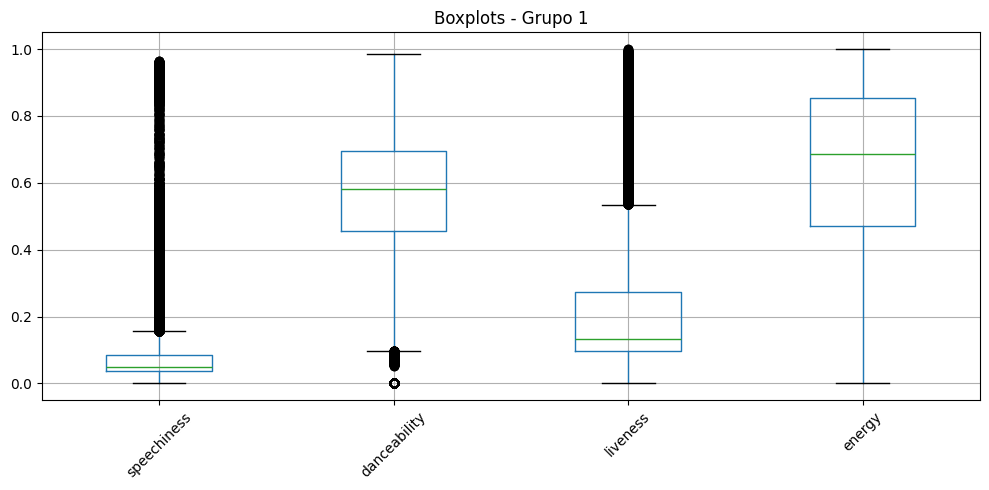

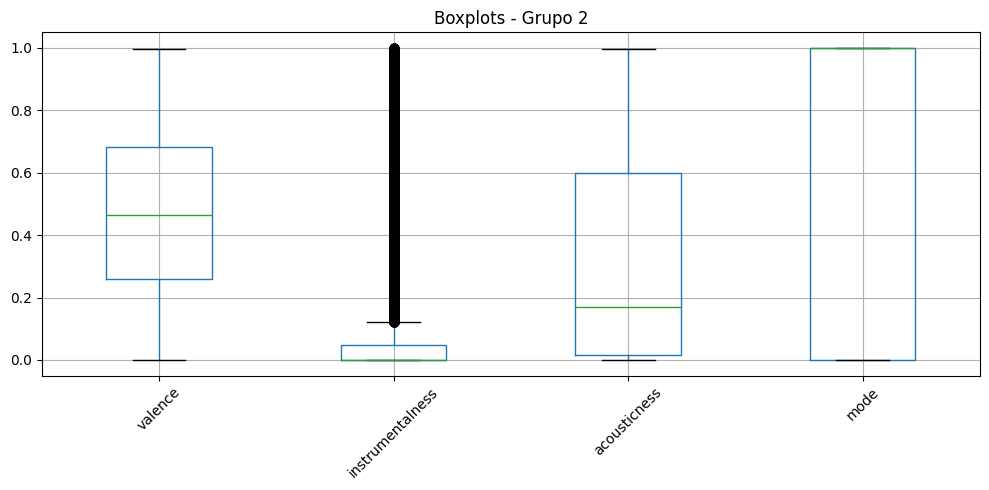

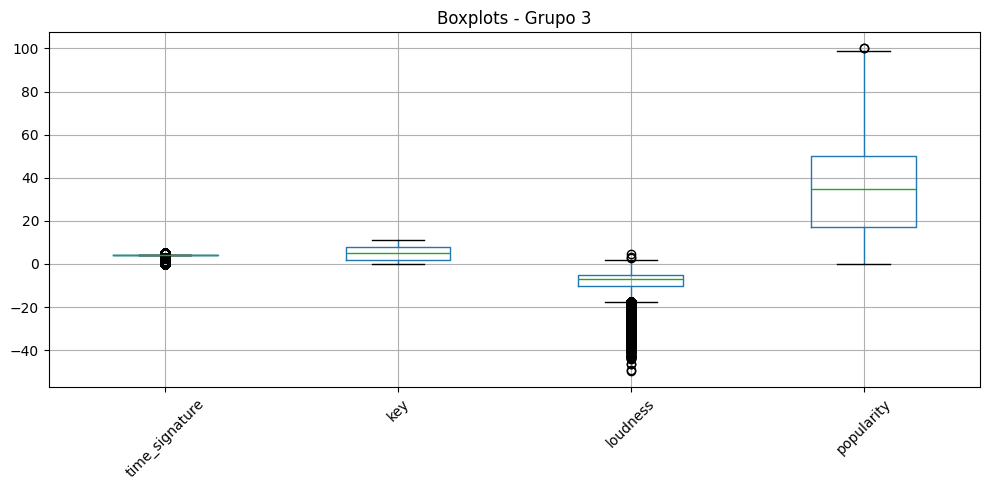

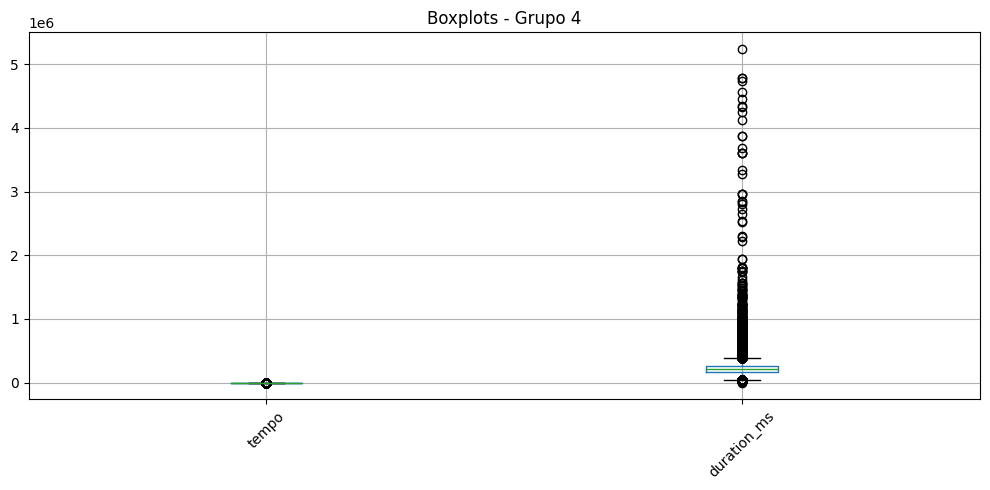

In [53]:
for i, grupo in enumerate(grupos, 1):
    plt.figure(figsize=(10, 5))
    df[grupo].boxplot(rot=45)
    plt.title(f"Boxplots - Grupo {i}")
    plt.tight_layout()
    plt.show()

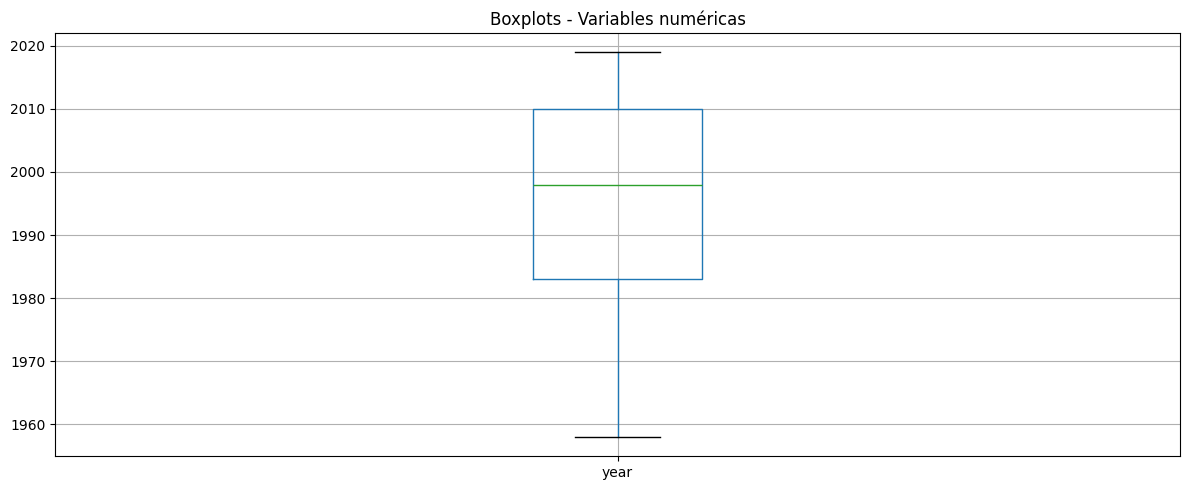

In [54]:
import matplotlib.pyplot as plt

numeric_cols = dataframes["the_grammy_awards"].select_dtypes(include='number').columns

dataframes["the_grammy_awards"][numeric_cols].boxplot(figsize=(12, 5), rot=0)
plt.title("Boxplots - Variables numéricas")
plt.tight_layout()
plt.show()

In [55]:
df = dataframes["the_grammy_awards"].copy()

def detect_datetime_format(x):
    if pd.isnull(x):
        return "null"
    
    x = str(x).strip()

    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", x):
        return "YYYY-MM-DD"
    elif re.fullmatch(r"\d{4}/\d{2}/\d{2}", x):
        return "YYYY/MM/DD"
    elif re.fullmatch(r"\d{2}-\d{2}-\d{4}", x):
        return "DD-MM-YYYY"
    elif re.fullmatch(r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}[+-]\d{2}:\d{2}", x):
        return "ISO8601_datetime_timezone"
    else:
        return "other"

formats = df["published_at"].apply(detect_datetime_format)

print("DATE FORMAT DISTRIBUTION:")
print(formats.value_counts())

DATE FORMAT DISTRIBUTION:
published_at
ISO8601_datetime_timezone    4810
Name: count, dtype: int64


In [56]:
df = dataframes["the_grammy_awards"].copy()

# Extraer año del título, por ejemplo: "62nd Annual GRAMMY Awards (2019)"
df["year_in_title"] = df["title"].str.extract(r"\((\d{4})\)")

# Convertir a numérico
df["year_in_title"] = pd.to_numeric(df["year_in_title"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Comparar
df["year_matches_title"] = df["year"] == df["year_in_title"]

# Resumen
print(df["year_matches_title"].value_counts(dropna=False))

year_matches_title
True    4810
Name: count, dtype: int64


In [57]:
df = dataframes["the_grammy_awards"].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)

df["published_year"] = df["published_at"].dt.year

df["year_less_than_published"] = df["year"] < df["published_year"]
df["year_less_or_equal_published"] = df["year"] <= df["published_year"]

print("year < published_year")
print(df["year_less_than_published"].value_counts(dropna=False))

print("\nyear <= published_year")
print(df["year_less_or_equal_published"].value_counts(dropna=False))

year < published_year
year_less_than_published
True     4724
False      86
Name: count, dtype: int64

year <= published_year
year_less_or_equal_published
True    4810
Name: count, dtype: int64


In [58]:
df = dataframes["the_grammy_awards"].copy()

# Convertir a fecha
df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce", utc=True)
df["updated_at"] = pd.to_datetime(df["updated_at"], errors="coerce", utc=True)

# Validación
df["updated_not_less_than_published"] = df["updated_at"] >= df["published_at"]

# Resumen
print(df["updated_not_less_than_published"].value_counts(dropna=False))

updated_not_less_than_published
True    4810
Name: count, dtype: int64


In [59]:
#Reports
from ydata_profiling import ProfileReport

/Users/valemoravale/Documents/UNIVERSIDAD /Semestre 5/ETL/workshop2/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [60]:
Path("reports").mkdir(exist_ok=True)

spotify_df = pd.read_csv("raw/spotify_dataset.csv")
grammy_df = pd.read_csv("raw/the_grammy_awards.csv")

spotify_profile = ProfileReport(spotify_df, title="Spotify Data Profile", explorative=True)
spotify_profile.to_file("reports/spotify_report.html")

grammy_profile = ProfileReport(grammy_df, title="Grammy Data Profile", explorative=True)
grammy_profile.to_file("reports/grammy_report.html")

print("Reportes generados en la carpeta reports")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 521.87it/s]

Reportes generados en la carpeta reports
